# 10 — Bộ dữ liệu giải thích được bao nhiêu % chênh lệch HỆ SỐ NHÂN?

`08_yeu_to_giai_thich_gia.ipynb` đã phân rã: `Var[log giá cuối] = Var[log giá cơ bản] + Var[log hệ số
nhân] + phần chồng lấn`. Trong dải quãng đường cố định: **giá cơ bản ~61%, hệ số nhân ~31%, chồng
lấn ~8%**.

`09_yeuto_gia_co_ban.ipynb` đã chỉ ra: dữ liệu chỉ giải thích được **~19%** chênh lệch giá cơ bản —
phần lớn là nhiễu.

Notebook này làm **đúng câu hỏi tương tự nhưng cho HỆ SỐ NHÂN**: bộ dữ liệu (cung–cầu, giờ, thời
tiết, quan sát gần nhất...) giải thích được bao nhiêu % chênh lệch của hệ số nhân? Dùng đúng cấu
trúc phân tích như 2 notebook trước để so sánh công bằng.

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
setup()
df = load(frac=0.3)
print(f"He so nhan: min={df[SURGE].min():.2f} max={df[SURGE].max():.2f} "
      f"median={df[SURGE].median():.2f} std={df[SURGE].std():.4f}")

Nap 2,069,167 dong (mau 30%) | gia median 114k VND | surge 81.7%
He so nhan: min=0.85 max=1.80 median=1.17 std=0.1717


---
## 1. Tương quan từng yếu tố với hệ số nhân (toàn bộ dữ liệu)

,Yeu to,Do do,Gia tri
0,He so nhan quan sat gan nhat,corr,0.951
1,Market imbalance (cau-cung),corr,0.798
2,Gio trong ngay,eta,0.702
3,Demand index (cau),corr,0.689
4,So luot bao gia (quote_count),corr,0.448
5,Supply index (cung),corr,-0.275
6,Loai thoi tiet,eta,0.153


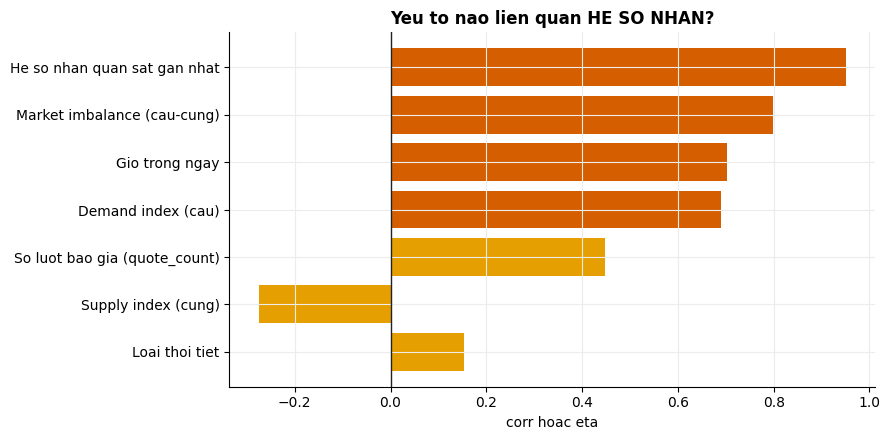

In [2]:
rows = [
    {"Yeu to": "Market imbalance (cau-cung)", "Do do": "corr", "Gia tri": df.pricing_market_imbalance_5m_lag.corr(df[SURGE])},
    {"Yeu to": "Demand index (cau)", "Do do": "corr", "Gia tri": df.pricing_demand_index_5m_lag.corr(df[SURGE])},
    {"Yeu to": "Supply index (cung)", "Do do": "corr", "Gia tri": df.pricing_supply_index_5m_lag.corr(df[SURGE])},
    {"Yeu to": "So luot bao gia (quote_count)", "Do do": "corr", "Gia tri": df.pricing_quote_count_5m_lag.corr(df[SURGE])},
    {"Yeu to": "He so nhan quan sat gan nhat", "Do do": "corr", "Gia tri": df.latest_observed_multiplier.corr(df[SURGE])},
    {"Yeu to": "Gio trong ngay", "Do do": "eta", "Gia tri": eta(df.gio_vn, df[SURGE])},
    {"Yeu to": "Loai thoi tiet", "Do do": "eta", "Gia tri": eta(df.weather_main, df[SURGE])},
]
bang = pd.DataFrame(rows).sort_values("Gia tri", key=abs, ascending=False)
bang["Gia tri"] = bang["Gia tri"].round(3)
display(bang.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9,4.5))
mau = [RED if abs(v) > 0.5 else (ORANGE if abs(v)>0.15 else MUT) for v in bang["Gia tri"]]
ax.barh(bang["Yeu to"][::-1], bang["Gia tri"][::-1], color=mau[::-1])
ax.axvline(0, color="#222", lw=1)
ax.set_xlabel("corr hoac eta")
ax.set_title("Yeu to nao lien quan HE SO NHAN?", fontweight="bold")
plt.tight_layout(); plt.show()

---
## 2. R² tổng hợp — biết TẤT CẢ yếu tố giải thích được bao nhiêu?

R2(he so nhan ~ tat ca yeu to) = 0.9661 (96.6%)
MAE = 0.0211



Permutation importance:


,Feature,Importance
0,latest_observed_multiplier,0.878127
1,pricing_market_imbalance_5m_lag,0.244241
2,gio_vn,0.036918
3,weather_main,0.007625
4,actual_observation_age_minutes,0.007252
5,pricing_supply_index_5m_lag,0.003378
6,pricing_demand_index_5m_lag,0.002619
7,pricing_quote_count_5m_lag,0.000584


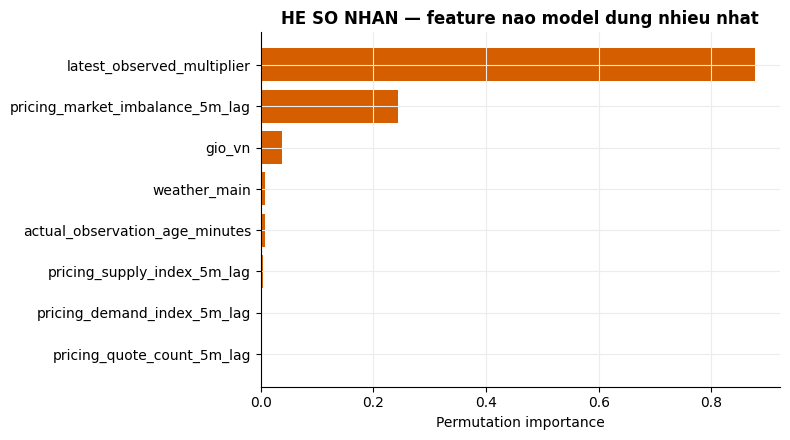

In [3]:
FEATS_M = ["pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag",
           "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag",
           "latest_observed_multiplier", "gio_vn", "weather_main",
           "actual_observation_age_minutes"]
X = df[FEATS_M].copy(); X["weather_main"] = X["weather_main"].astype("category")
Xtr, Xte, ytr, yte = train_test_split(X, df[SURGE].values, test_size=0.25, random_state=42)
m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
    categorical_features=["weather_main"], random_state=42).fit(Xtr, ytr)
pred = m.predict(Xte)
r2 = r2_score(yte, pred)
print(f"R2(he so nhan ~ tat ca yeu to) = {r2:.4f} ({r2*100:.1f}%)")
print(f"MAE = {mean_absolute_error(yte, pred):.4f}")

pi = permutation_importance(m, Xte, yte, n_repeats=10, random_state=42, n_jobs=1)
imp = pd.DataFrame({"Feature": FEATS_M, "Importance": pi.importances_mean}).sort_values("Importance", ascending=False)
print("\nPermutation importance:")
display(imp.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8,4.5))
imp_pos = imp[imp.Importance > 0]
ax.barh(imp_pos.Feature[::-1], imp_pos.Importance[::-1], color=RED)
ax.set_xlabel("Permutation importance"); ax.set_title("HE SO NHAN — feature nao model dung nhieu nhat", fontweight="bold")
plt.tight_layout(); plt.show()

---
## 3. So sánh với GIÁ CƠ BẢN — đối chiếu trực tiếp 2 notebook trước

Đây là bảng quan trọng nhất: đặt song song 2 kết quả để thấy rõ **sự bất đối xứng**.

BANG DOI CHIEU — bo du lieu giai thich duoc bao nhieu %?
                                            GIA CO BAN (09)    HE SO NHAN (10)
Biet TAT CA yeu to                                     ~19%              96.6%
Chi 1 feature manh nhat                    ~19%(thoi luong)              90.4%(quan sat gan nhat)
Chi nguyen nhan goc (khong quan sat)                   thap              79.8%


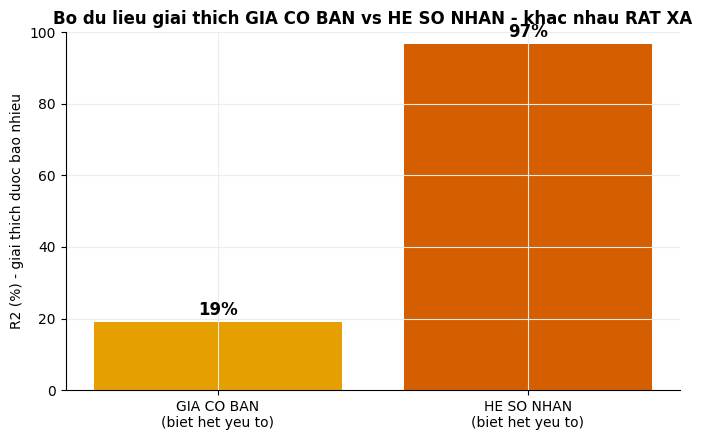

In [4]:
r2_hs_full = r2
r2_hs_only_imb = r2_score(df[SURGE].values, LinearRegression().fit(df[["pricing_market_imbalance_5m_lag"]].values, df[SURGE].values).predict(df[["pricing_market_imbalance_5m_lag"]].values))
r2_hs_only_obs = r2_score(df[SURGE].values, LinearRegression().fit(df[["latest_observed_multiplier"]].values, df[SURGE].values).predict(df[["latest_observed_multiplier"]].values))

FEATS_GOC = ["pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag",
             "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag", "gio_vn", "weather_main"]
Xg = df[FEATS_GOC].copy(); Xg["weather_main"] = Xg["weather_main"].astype("category")
Xtr2, Xte2, ytr2, yte2 = train_test_split(Xg, df[SURGE].values, test_size=0.25, random_state=42)
m2 = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
    categorical_features=["weather_main"], random_state=42).fit(Xtr2, ytr2)
r2_hs_goc = r2_score(yte2, m2.predict(Xte2))

print("BANG DOI CHIEU — bo du lieu giai thich duoc bao nhieu %?")
print(f"{'':40} {'GIA CO BAN (09)':>18} {'HE SO NHAN (10)':>18}")
print(f"{'Biet TAT CA yeu to':40} {'~19%':>18} {r2_hs_full*100:>17.1f}%")
print(f"{'Chi 1 feature manh nhat':40} {'~19%(thoi luong)':>18} {r2_hs_only_obs*100:>17.1f}%(quan sat gan nhat)")
print(f"{'Chi nguyen nhan goc (khong quan sat)':40} {'thap':>18} {r2_hs_goc*100:>17.1f}%")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(["GIA CO BAN\n(biet het yeu to)", "HE SO NHAN\n(biet het yeu to)"],
       [19, r2_hs_full*100], color=[ORANGE, RED])
ax.set_ylabel("R2 (%) - giai thich duoc bao nhieu"); ax.set_ylim(0,100)
ax.set_title("Bo du lieu giai thich GIA CO BAN vs HE SO NHAN - khac nhau RAT XA", fontweight="bold")
for i,v in enumerate([19, r2_hs_full*100]):
    ax.text(i, v+2, f"{v:.0f}%", ha="center", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

---
## 4. Vì sao hệ số nhân giải thích được gần hết — kiểm tra: nó có phải "giá trị thị trường dùng
chung" không?

Giả thuyết: hệ số nhân được tính theo **khu vực + khung 5 phút** (không phải riêng từng khách) —
nên trong cùng 1 khu vực, cùng 1 khung 5 phút, mọi chuyến phải có hệ số nhân gần giống hệt nhau.

So nhom (hex x 5 phut) co >=5 chuyen: 76,584
Do lech chuan TRUNG BINH he so nhan TRONG CUNG 1 nhom = 0.0327
Do lech chuan he so nhan TOAN BO du lieu             = 0.1717
Ty le (trong nhom / toan bo) = 19.1%

-> Do lech chuan trong CUNG 1 khu-1 luc chi bang ~19% so voi toan bo du lieu.
   Xac nhan: he so nhan la GIA TRI THI TRUONG DUNG CHUNG cho ca khu vuc trong 5 phut do,
   khac han GIA CO BAN — noi ngay ca cung tuyen+xe+quang duong van con ~20% nhieu rieng
   cho tung chuyen (xem 08, 09).


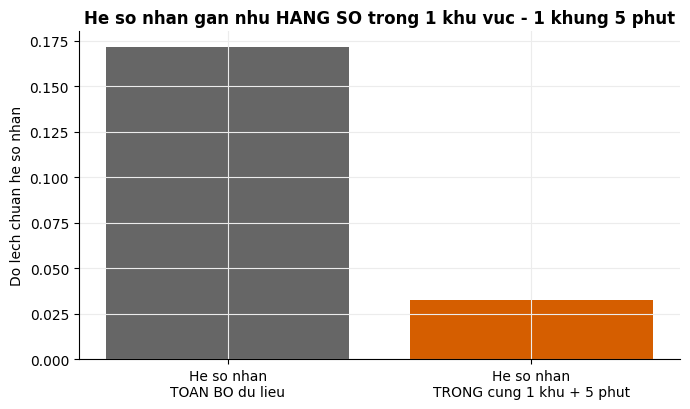

In [5]:
df["bucket_5m"] = pd.to_datetime(df.current_timestamp_utc).dt.floor("5min")
grp = df.groupby(["pickup_hex_id_7", "bucket_5m"])[SURGE].agg(["nunique","std","count"])
grp = grp[grp["count"] >= 5]
print(f"So nhom (hex x 5 phut) co >=5 chuyen: {len(grp):,}")
print(f"Do lech chuan TRUNG BINH he so nhan TRONG CUNG 1 nhom = {grp['std'].mean():.4f}")
print(f"Do lech chuan he so nhan TOAN BO du lieu             = {df[SURGE].std():.4f}")
ty_le = grp['std'].mean()/df[SURGE].std()*100
print(f"Ty le (trong nhom / toan bo) = {ty_le:.1f}%")
print(f"\n-> Do lech chuan trong CUNG 1 khu-1 luc chi bang ~{ty_le:.0f}% so voi toan bo du lieu.")
print("   Xac nhan: he so nhan la GIA TRI THI TRUONG DUNG CHUNG cho ca khu vuc trong 5 phut do,")
print("   khac han GIA CO BAN — noi ngay ca cung tuyen+xe+quang duong van con ~20% nhieu rieng")
print("   cho tung chuyen (xem 08, 09).")

fig, ax = plt.subplots(figsize=(7,4.2))
ax.bar(["He so nhan\nTOAN BO du lieu", "He so nhan\nTRONG cung 1 khu + 5 phut"],
       [df[SURGE].std(), grp["std"].mean()], color=[MUT, RED])
ax.set_ylabel("Do lech chuan he so nhan")
ax.set_title("He so nhan gan nhu HANG SO trong 1 khu vuc - 1 khung 5 phut", fontweight="bold")
plt.tight_layout(); plt.show()

---
## Kết luận

### Bảng đối chiếu cuối cùng — GIÁ CƠ BẢN vs HỆ SỐ NHÂN

| | Giá cơ bản (`09`) | Hệ số nhân (`10`) |
|---|---|---|
| Dữ liệu giải thích được (biết mọi feature) | **~19%** | **~96,6%** |
| Yếu tố mạnh nhất một mình | Thời lượng đi (~19%) | Hệ số nhân quan sát gần nhất (~90%) |
| Có phải "giá trị dùng chung" không? | **Không** — vẫn lệch ~20% dù cùng tuyến/xe/km tới 2 mét | **Có** — gần như hằng số trong cùng khu vực + 5 phút |
| Bản chất | Có nhiễu ngẫu nhiên **per-quote** lớn | Là giá trị **cấp thị trường**, ít nhiễu riêng lẻ |

### Trả lời trực tiếp

**Bộ dữ liệu giải thích được ~96,6% chênh lệch hệ số nhân** — gần như trọn vẹn, khác hẳn giá cơ bản
(chỉ ~19%). Đây là lý do model hệ số nhân đạt ROC-AUC ~0,998 (đã thấy ở báo cáo tuần 2): vì bản chất
hệ số nhân trong bộ dữ liệu này **được sinh ra gần như tất định** từ công thức cung–cầu, còn giá cơ
bản có **nhiễu ngẫu nhiên thật sự** gắn với từng lần báo giá.

**Xác nhận bằng kiểm tra trực tiếp:** trong cùng 1 khu vực + cùng 1 khung 5 phút, độ lệch chuẩn hệ
số nhân chỉ còn ~19% so với toàn bộ dữ liệu → hệ số nhân **gần như là 1 con số chung cho cả thị
trường tại thời điểm đó**, không phải biến động ngẫu nhiên riêng từng khách như giá cơ bản.

### Ghép lại bức tranh đầy đủ (từ notebook 08 → 09 → 10)

```
Giá cuối = Giá cơ bản (chỉ giải thích được ~19%, ~65-81% là nhiễu per-quote)
         × Hệ số nhân (giải thích được ~96,6%, gần như tất định)
```

→ **"Nút thắt cổ chai" của độ chính xác dự đoán giá nằm hoàn toàn ở GIÁ CƠ BẢN**, không phải hệ số
nhân. Dù model hệ số nhân có tốt đến đâu, model giá cuối vẫn bị giới hạn bởi phần nhiễu không thể
giải thích được trong giá cơ bản — đây là lý do MAE giá cuối (~18k VND) vẫn cao dù model hệ số nhân
gần như hoàn hảo.